In [ ]:
import os, json, time, math
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, CSVLogger, TensorBoard, Callback

from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Global speed optimizations (safe)
# =========================
try:
    from tensorflow.keras import mixed_precision
    policy = mixed_precision.Policy("mixed_float16")
    mixed_precision.set_global_policy(policy)
    print(f"[INFO] Mixed precision enabled: {policy.name}")
except Exception as e:
    print("[INFO] Mixed precision not enabled:", e)

try:
    tf.config.optimizer.set_jit(True)
    print("[INFO] XLA JIT enabled.")
except Exception as e:
    print("[INFO] XLA JIT not enabled:", e)

AUTOTUNE = tf.data.AUTOTUNE
dopt = tf.data.Options()
dopt.experimental_deterministic = False   # ok to be nondeterministic for speed

# =========================
# Config
# =========================
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 50
SEED = 1337

# what to run
MODELS = ['xception', 'vgg16', 'resnet50', 'googlenet', 'mobilenet', 'densenet', 'lenet', 'alexnet', 'efficientnet']
DATASET_VERSIONS = ['img_is2_v1', 'img_is2_v2', 'img_is2_v3']  # <- your 3 folders

# output dirs
LOG_ROOT   = "logs"
CACHE_ROOT = ".tf_cache_img_is2"
OUT_DIR    = "outputs"
PLOT_DIR   = os.path.join(OUT_DIR, "plots")
os.makedirs(PLOT_DIR, exist_ok=True)

# =========================
# Datasets
# =========================
def make_ds(directory, training=False, cache_path=None):
    ds = tf.keras.preprocessing.image_dataset_from_directory(
        directory,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode='int',
        shuffle=training,
        seed=SEED
    )
    ds = ds.with_options(dopt)
    if cache_path:
        os.makedirs(os.path.dirname(cache_path), exist_ok=True)
        ds = ds.cache(cache_path)
    else:
        ds = ds.cache()
    if training:
        ds = ds.shuffle(1000, seed=SEED, reshuffle_each_iteration=True)
    ds = ds.prefetch(AUTOTUNE)
    return ds

# =========================
# Callbacks / utilities
# =========================
class EpochTimer(Callback):
    def on_train_begin(self, logs=None):
        self.epoch_times = []
        print("\n[TRAIN] Starting…")
    def on_epoch_begin(self, epoch, logs=None):
        self._t0 = time.time()
    def on_epoch_end(self, epoch, logs=None):
        t = time.time() - self._t0
        self.epoch_times.append(t)
        avg = np.mean(self.epoch_times)
        remaining = (self.params['epochs'] - (epoch+1)) * avg
        msg = (f"[EPOCH {epoch+1}/{self.params['epochs']}] "
               f"time={t:.1f}s avg={avg:.1f}s "
               f"loss={logs.get('loss'):.4f} acc={logs.get('accuracy'):.4f} "
               f"val_loss={logs.get('val_loss'):.4f} val_acc={logs.get('val_accuracy'):.4f} "
               f"ETA~{remaining/60:.1f}m")
        print(msg)

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# =========================
# Preprocess mapping per backbone
# =========================
def get_backbone_and_preprocess(name):
    name = name.lower()
    if name == 'vgg16':
        from tensorflow.keras.applications import VGG16
        from tensorflow.keras.applications.vgg16 import preprocess_input
        return (lambda: VGG16(include_top=False, input_shape=(*IMG_SIZE,3), weights='imagenet'),
                layers.Lambda(preprocess_input, name="preprocess"))
    if name == 'resnet50':
        from tensorflow.keras.applications import ResNet50
        from tensorflow.keras.applications.resnet50 import preprocess_input
        return (lambda: ResNet50(include_top=False, input_shape=(*IMG_SIZE,3), weights='imagenet'),
                layers.Lambda(preprocess_input, name="preprocess"))
    if name in ('googlenet', 'inceptionv3'):
        from tensorflow.keras.applications import InceptionV3
        from tensorflow.keras.applications.inception_v3 import preprocess_input
        return (lambda: InceptionV3(include_top=False, input_shape=(*IMG_SIZE,3), weights='imagenet'),
                layers.Lambda(preprocess_input, name="preprocess"))
    if name == 'xception':
        from tensorflow.keras.applications import Xception
        from tensorflow.keras.applications.xception import preprocess_input
        return (lambda: Xception(include_top=False, input_shape=(*IMG_SIZE,3), weights='imagenet'),
                layers.Lambda(preprocess_input, name="preprocess"))
    if name == 'mobilenet':
        from tensorflow.keras.applications import MobileNetV2
        from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
        return (lambda: MobileNetV2(include_top=False, input_shape=(*IMG_SIZE,3), weights='imagenet'),
                layers.Lambda(preprocess_input, name="preprocess"))
    if name == 'densenet':
        from tensorflow.keras.applications import DenseNet121
        from tensorflow.keras.applications.densenet import preprocess_input
        return (lambda: DenseNet121(include_top=False, input_shape=(*IMG_SIZE,3), weights='imagenet'),
                layers.Lambda(preprocess_input, name="preprocess"))
    if name == 'efficientnet':
        from tensorflow.keras.applications import EfficientNetB0
        from tensorflow.keras.applications.efficientnet import preprocess_input
        return (lambda: EfficientNetB0(include_top=False, input_shape=(*IMG_SIZE,3), weights='imagenet'),
                layers.Lambda(preprocess_input, name="preprocess"))
    return (None, None)

# =========================
# Model builders
# =========================
def create_transfer_model(name):
    base_fn, preprocess_layer = get_backbone_and_preprocess(name)
    if base_fn is None:
        raise ValueError(f"No backbone for {name}")
    inputs = layers.Input(shape=(*IMG_SIZE, 3))
    x = preprocess_layer(inputs)
    base = base_fn()
    base.trainable = False
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(1024, activation='relu')(x)
    outputs = layers.Dense(1, activation='sigmoid', dtype='float32')(x)
    model = Model(inputs, outputs, name=f"{name}_binary")
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def create_lenet():
    return tf.keras.Sequential([
        layers.Input(shape=(*IMG_SIZE,3)),
        layers.Conv2D(6, (5,5), activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(16, (5,5), activation='relu'),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(120, activation='relu'),
        layers.Dense(84, activation='relu'),
        layers.Dense(1, activation='sigmoid', dtype='float32')
    ], name="lenet_binary")

def create_alexnet():
    return tf.keras.Sequential([
        layers.Input(shape=(*IMG_SIZE,3)),
        layers.Conv2D(96, (11,11), strides=4, activation='relu'),
        layers.MaxPooling2D((3,3), strides=2),
        layers.Conv2D(256, (5,5), padding='same', activation='relu'),
        layers.MaxPooling2D((3,3), strides=2),
        layers.Conv2D(384, (3,3), padding='same', activation='relu'),
        layers.Conv2D(384, (3,3), padding='same', activation='relu'),
        layers.Conv2D(256, (3,3), padding='same', activation='relu'),
        layers.MaxPooling2D((3,3), strides=2),
        layers.Flatten(),
        layers.Dense(4096, activation='relu'),
        layers.Dense(4096, activation='relu'),
        layers.Dense(1, activation='sigmoid', dtype='float32')
    ], name="alexnet_binary")

def compile_simple(model):
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# =========================
# Train / evaluate helpers
# =========================
def train_and_select_epoch(history):
    # pick the epoch with best val_loss
    best_idx = int(np.argmin(history.history['val_loss']))
    result = {
        "best_epoch": best_idx + 1,
        "train_loss": float(history.history['loss'][best_idx]),
        "train_accuracy": float(history.history['accuracy'][best_idx]),
        "val_loss": float(history.history['val_loss'][best_idx]),
        "val_accuracy": float(history.history['val_accuracy'][best_idx]),
    }
    return result

def collect_preds(ds, model):
    y_true = []
    y_prob = []
    for batch, labels in ds:
        preds = model.predict(batch, verbose=0).ravel()
        y_true.append(labels.numpy())
        y_prob.append(preds)
    y_true = np.concatenate(y_true)
    y_prob = np.concatenate(y_prob)
    y_pred = (y_prob >= 0.5).astype(int)
    return y_true, y_pred, y_prob

def plot_bar(df, title, save_path, ylabel="Score"):
    plt.figure(figsize=(10,6))
    ax = df.plot(kind='bar')
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.close()

def train_evaluate_one(dataset_version, model_name, train_ds, val_ds, test_ds):
    print(f"\n========== [{dataset_version}] Training {model_name} ==========")
    run_log_dir = os.path.join(LOG_ROOT, dataset_version, model_name, time.strftime('%Y%m%d-%H%M%S'))
    os.makedirs(run_log_dir, exist_ok=True)

    # build model
    if model_name == 'lenet':
        model = compile_simple(create_lenet())
    elif model_name == 'alexnet':
        model = compile_simple(create_alexnet())
    else:
        model = create_transfer_model(model_name)

    callbacks = [
        EpochTimer(),
        early_stopping,
        CSVLogger(os.path.join(run_log_dir, "training.csv")),
        TensorBoard(log_dir=run_log_dir, histogram_freq=0)
    ]

    history = model.fit(
        train_ds, validation_data=val_ds, epochs=EPOCHS,
        callbacks=callbacks, verbose=0
    )

    best = train_and_select_epoch(history)
    print(f"[{dataset_version}][{model_name}] best_epoch={best['best_epoch']} "
          f"val_acc={best['val_accuracy']:.4f} val_loss={best['val_loss']:.4f}")

    # Evaluate on test with best weights restored
    test_loss, test_acc = model.evaluate(test_ds, verbose=0)
    best["test_loss"] = float(test_loss)
    best["test_accuracy"] = float(test_acc)

    # Classification report on test
    y_true, y_pred, y_prob = collect_preds(test_ds, model)
    target_names = ['PASS', 'FAIL']  # assumes 0: PASS, 1: FAIL
    report = classification_report(y_true, y_pred, target_names=target_names, output_dict=True, zero_division=0)

    return best, report, model  # (metrics dict), (classification dict), model for optional saving

# =========================
# Main loop
# =========================
summary_rows = []  # train/val/test metrics
cr_rows = []       # classification report rows (per-class + macro/weighted)

for dv in DATASET_VERSIONS:
    print(f"\n\n================= DATASET: {dv} =================")
    train_dir = os.path.join(dv, "train")
    val_dir   = os.path.join(dv, "validate")
    test_dir  = os.path.join(dv, "test")

    train_ds = make_ds(train_dir, training=True,  cache_path=os.path.join(CACHE_ROOT, dv, "train.cache"))
    val_ds   = make_ds(val_dir,   training=False, cache_path=os.path.join(CACHE_ROOT, dv, "val.cache"))
    test_ds  = make_ds(test_dir,  training=False, cache_path=os.path.join(CACHE_ROOT, dv, "test.cache"))

    for model_name in MODELS:
        metrics, cr_dict, _model = train_evaluate_one(dv, model_name, train_ds, val_ds, test_ds)

        # Save history-like summary rows for train/val/test
        summary_rows.append({
            "dataset": dv, "model": model_name, "split": "train",
            "loss": metrics["train_loss"], "accuracy": metrics["train_accuracy"],
            "best_epoch": metrics["best_epoch"]
        })
        summary_rows.append({
            "dataset": dv, "model": model_name, "split": "val",
            "loss": metrics["val_loss"], "accuracy": metrics["val_accuracy"],
            "best_epoch": metrics["best_epoch"]
        })
        summary_rows.append({
            "dataset": dv, "model": model_name, "split": "test",
            "loss": metrics["test_loss"], "accuracy": metrics["test_accuracy"],
            "best_epoch": metrics["best_epoch"]
        })

        # Flatten classification report into rows
        for label in list(cr_dict.keys()):
            if label in ("accuracy",):  # accuracy is a single number
                cr_rows.append({
                    "dataset": dv, "model": model_name, "label": "accuracy",
                    "precision": np.nan,
                    "recall":    np.nan,
                    "f1":        float(cr_dict["accuracy"]),
                    "support":   sum(v["support"] for k,v in cr_dict.items() if isinstance(v, dict) and "support" in v)
                })
            elif isinstance(cr_dict[label], dict):
                entry = cr_dict[label]
                cr_rows.append({
                    "dataset": dv, "model": model_name, "label": label,
                    "precision": float(entry.get("precision", np.nan)),
                    "recall":    float(entry.get("recall", np.nan)),
                    "f1":        float(entry.get("f1-score", np.nan)),
                    "support":   int(entry.get("support", 0))
                })

# =========================
# Save aggregated results (ONE FILE for everything)
# =========================
os.makedirs(OUT_DIR, exist_ok=True)
summary_df = pd.DataFrame(summary_rows)
cr_df      = pd.DataFrame(cr_rows)

# One combined file that contains both tables (as CSV sections concatenated with markers)
combined_path = os.path.join(OUT_DIR, "results_summary.csv")
summary_df.to_csv(combined_path, index=False)
print(f"[SAVE] Train/Val/Test metrics saved -> {combined_path}")

cr_path = os.path.join(OUT_DIR, "classification_report.csv")
cr_df.to_csv(cr_path, index=False)
print(f"[SAVE] Classification reports saved -> {cr_path}")

# Also save as JSON for programmatic use if you want a single JSON blob:
combined_json_path = os.path.join(OUT_DIR, "results_all.json")
with open(combined_json_path, "w") as f:
    json.dump({
        "metrics": summary_rows,
        "classification_report": cr_rows
    }, f, indent=2)
print(f"[SAVE] Combined JSON -> {combined_json_path}")

# =========================
# Charts for comparison
# =========================
# 1) Macro-F1 by dataset/model (from classification report)
macro_df = cr_df[cr_df["label"]=="macro avg"][["dataset","model","f1"]].copy()
for dv in DATASET_VERSIONS:
    m = macro_df[macro_df["dataset"]==dv].set_index("model").sort_values("f1")
    save_path = os.path.join(PLOT_DIR, f"macro_f1_{dv}.png")
    plot_bar(m, f"Macro F1 (test) – {dv}", save_path, ylabel="Macro F1")
    print(f"[PLOT] {save_path}")

# 2) Accuracy (test) by dataset/model
acc_df = summary_df[summary_df["split"]=="test"][["dataset","model","accuracy"]].copy()
for dv in DATASET_VERSIONS:
    a = acc_df[acc_df["dataset"]==dv].set_index("model").sort_values("accuracy")
    save_path = os.path.join(PLOT_DIR, f"test_accuracy_{dv}.png")
    plot_bar(a, f"Test Accuracy – {dv}", save_path, ylabel="Accuracy")
    print(f"[PLOT] {save_path}")

# 3) Per-class F1 comparison (test) across models for each dataset
for dv in DATASET_VERSIONS:
    per_class = cr_df[(cr_df["dataset"]==dv) & (cr_df["label"].isin(["PASS","FAIL"]))][["model","label","f1"]]
    if per_class.empty: 
        continue
    pivot = per_class.pivot(index="model", columns="label", values="f1").fillna(0.0).sort_values(by=list(per_class["label"].unique()))
    save_path = os.path.join(PLOT_DIR, f"per_class_f1_{dv}.png")
    plot_bar(pivot, f"Per-class F1 (test) – {dv}", save_path, ylabel="F1")
    print(f"[PLOT] {save_path}")

print("\nAll done! Open the images in outputs/plots/ and explore CSVs in outputs/.")
print("Tip: run `tensorboard --logdir logs` to see per-run training curves.")


[INFO] Mixed precision enabled: mixed_float16
[INFO] XLA JIT enabled.


================= DATASET: img_is2_v1 =================
Found 8856 files belonging to 2 classes.
Found 1476 files belonging to 2 classes.
Found 1477 files belonging to 2 classes.

========== [img_is2_v1] Training xception ==========

[TRAIN] Starting…
[EPOCH 1/50] time=53.9s avg=53.9s loss=0.7238 acc=0.5217 val_loss=0.7128 val_acc=0.5000 ETA~44.0m
[EPOCH 2/50] time=47.1s avg=50.5s loss=0.6883 acc=0.5456 val_loss=0.6866 val_acc=0.5000 ETA~40.4m
[EPOCH 3/50] time=41.4s avg=47.4s loss=0.6875 acc=0.5474 val_loss=0.6732 val_acc=0.5705 ETA~37.2m
[EPOCH 4/50] time=41.6s avg=46.0s loss=0.6820 acc=0.5553 val_loss=0.6764 val_acc=0.5854 ETA~35.3m
[EPOCH 5/50] time=37.6s avg=44.3s loss=0.6791 acc=0.5561 val_loss=0.6619 val_acc=0.5684 ETA~33.2m
[EPOCH 6/50] time=36.9s avg=43.1s loss=0.6766 acc=0.5675 val_loss=0.6663 val_acc=0.5874 ETA~31.6m
[EPOCH 7/50] time=37.4s avg=42.2s loss=0.6727 acc=0.5685 val_loss=0.6560 val_acc=0.5874 

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [13]:
df = pd.read_csv(r'D:\QDS\coding\OQA failure prediction\outputs\classification_report.csv')
df[df['dataset']=='img_is2_v1'].head()

,dataset,model,label,precision,recall,f1,support
0,img_is2_v1,xception,PASS,0.797030,0.218453,0.342918,737.0
1,img_is2_v1,xception,FAIL,0.548235,0.944595,0.693797,740.0
2,img_is2_v1,xception,accuracy,NaN,NaN,0.582261,4431.0
3,img_is2_v1,xception,macro avg,0.672632,0.581524,0.518357,1477.0
4,img_is2_v1,xception,weighted avg,0.672380,0.582261,0.518714,1477.0


In [27]:
import json
import pandas as pd

# Read JSON from file
with open(r"D:\QDS\coding\OQA failure prediction\outputs_20\results_all.json", "r") as f:  # replace with your filename
    data = json.load(f)

# Convert each section into a DataFrame
df_metrics = pd.DataFrame(data["metrics"])
df_report = pd.DataFrame(data["classification_report"])

# Show previews
print("Metrics DataFrame:")
print(df_metrics.head(), "\n")

print("Classification Report DataFrame:")
print(df_report.head(), "\n")

# Optional: save to CSV for further use
df_metrics.to_csv("metrics.csv", index=False)
df_report.to_csv("classification_report.csv", index=False)


Metrics DataFrame:
      dataset     model  split      loss  accuracy  best_epoch
0  img_is2_v1  xception  train  0.667931  0.571816          11
1  img_is2_v1  xception    val  0.645932  0.588076          11
2  img_is2_v1  xception   test  0.654030  0.583615          11
3  img_is2_v1     vgg16  train  0.664231  0.576219          20
4  img_is2_v1     vgg16    val  0.640619  0.586043          20 

Classification Report DataFrame:
      dataset     model         label  precision    recall        f1  support
0  img_is2_v1  xception          PASS   0.901316  0.185889  0.308211    737.0
1  img_is2_v1  xception          FAIL   0.547170  0.979730  0.702179    740.0
2  img_is2_v1  xception      accuracy        NaN       NaN  0.583615   4431.0
3  img_is2_v1  xception     macro avg   0.724243  0.582809  0.505195   1477.0
4  img_is2_v1  xception  weighted avg   0.723883  0.583615  0.505595   1477.0 



In [28]:
df_metrics[(df_metrics['dataset']=='img_is2_v3') & (df_metrics['split']=='test')]

,dataset,model,split,loss,accuracy,best_epoch
56,img_is2_v3,xception,test,0.674279,0.584293,18
59,img_is2_v3,vgg16,test,0.671087,0.588355,2
62,img_is2_v3,resnet50,test,0.681608,0.567366,1
65,img_is2_v3,googlenet,test,0.678308,0.557888,13
68,img_is2_v3,mobilenet,test,0.680076,0.554502,1
71,img_is2_v3,densenet,test,0.671913,0.511848,18
74,img_is2_v3,lenet,test,0.689798,0.549763,4
77,img_is2_v3,alexnet,test,0.693146,0.501016,3
80,img_is2_v3,efficientnet,test,0.693281,0.501016,3


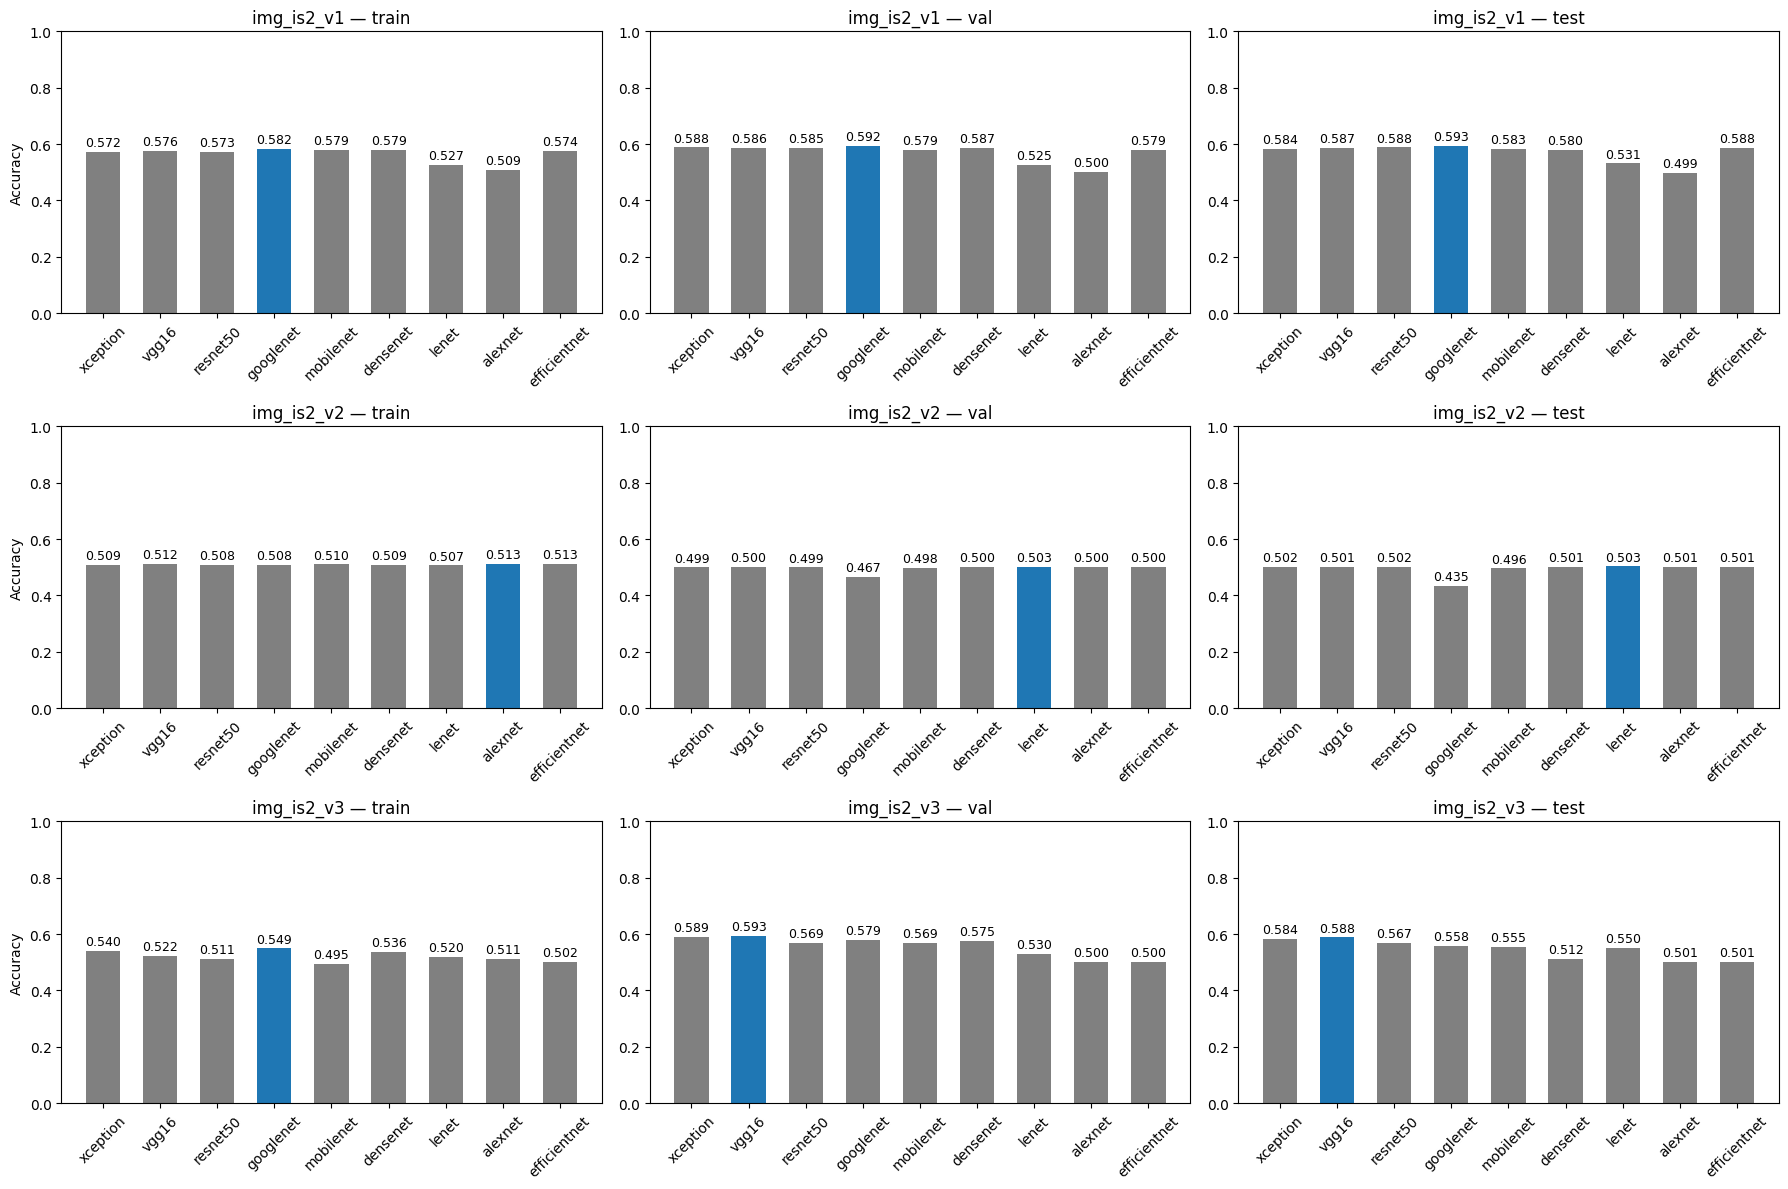

In [30]:
import matplotlib.pyplot as plt
import numpy as np

datasets = df_metrics["dataset"].unique()
splits = ["train", "val", "test"]

fig, axes = plt.subplots(len(datasets), len(splits), figsize=(18, 12), sharex=False)

# Ensure axes is always 2D
if len(datasets) == 1:
    axes = [axes]

for i, ds in enumerate(datasets):
    for j, split in enumerate(splits):
        ax = axes[i][j] if len(datasets) > 1 else axes[j]

        subset = df_metrics[(df_metrics["dataset"] == ds) & (df_metrics["split"] == split)]
        x = np.arange(len(subset))

        # Find best accuracy index
        best_idx = subset["accuracy"].idxmax()

        # Assign colors
        colors = ["tab:blue" if idx == best_idx else "gray" for idx in subset.index]

        # Plot bars
        bars = ax.bar(x, subset["accuracy"], width=0.6, color=colors)

        # Add values above bars
        for bar, val in zip(bars, subset["accuracy"]):
            ax.text(
                bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f"{val:.3f}",
                ha='center', va='bottom', fontsize=9
            )

        ax.set_xticks(x)
        ax.set_xticklabels(subset["model"], rotation=45)
        ax.set_ylim(0, 1)
        ax.set_title(f"{ds} — {split}")
        if j == 0:
            ax.set_ylabel("Accuracy")

plt.tight_layout()
plt.show()
